# Feature Selection — Metadata Engineering and Correlation Analysis

This notebook reproduces the complete feature selection analysis that identified the final 9 metadata features for multimodal misinformation detection.

**Goal:** Engineer features from raw ads data, analyze statistical properties, correlations, and redundancies, then select the optimal 9-feature set for model training.

In [1]:
# Add project root to path
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / 'src'))

# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, pointbiserialr
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
import json
import warnings
warnings.filterwarnings('ignore')

# Project imports
from data.feature_engineering import engineer_all_features

# Configure logging
import logging
logging.basicConfig(level=logging.INFO, format='[%(levelname)s] %(message)s')
logger = logging.getLogger(__name__)

# Configuration
RAW_CSV = '../data/raw/ads_vietnam_clean.csv'
PROCESSED_DIR = '../data/processed'
FIGURES_DIR = '../outputs/figures/feature_selection'

# Create figures directory
Path(FIGURES_DIR).mkdir(parents=True, exist_ok=True)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✓ Imports and configuration complete.")
print(f"  Figures will be saved to: {FIGURES_DIR}")

✓ Imports and configuration complete.
  Figures will be saved to: ../outputs/figures/feature_selection


## 1. Feature Engineering

Load raw ads data and engineer all behavioral features using the `engineer_all_features()` function.

In [2]:
# Load raw data
print(f"Loading raw ads data from {RAW_CSV}...")
df = pd.read_csv(RAW_CSV)
print(f"✓ Loaded {len(df):,} rows × {len(df.columns)} columns")
print(f"\nColumns: {sorted(df.columns.tolist())}")

# Identify original columns
original_cols = set(df.columns)

# Engineer features
print("\n" + "="*80)
print("ENGINEERING FEATURES...")
print("="*80)
df = engineer_all_features(df)
print("\n" + "="*80)

# Identify new engineered columns
engineered_cols = sorted(list(set(df.columns) - original_cols))

print(f"\n✓ Feature engineering complete.")
print(f"  Before: {len(original_cols)} columns")
print(f"  After:  {len(df.columns)} columns")
print(f"  New features: {len(engineered_cols)}")
print(f"\nEngineered features ({len(engineered_cols)}):")
for i, col in enumerate(engineered_cols, 1):
    print(f"  {i}. {col}")

Loading raw ads data from ../data/raw/ads_vietnam_clean.csv...


[INFO] Starting feature engineering...
[INFO] Computing core metadata features...


✓ Loaded 16,678 rows × 18 columns

Columns: ['ad_    creation_time', 'ad_creative_bodies', 'ad_creative_link_titles', 'ad_delivery_start_time', 'ad_delivery_stop_time', 'ad_snapshot_url', 'currency', 'id', 'impressions', 'languages', 'misinformation', 'page_id', 'page_name', 'publisher_platforms', 'spend', 'target_ages', 'target_gender', 'target_locations']

ENGINEERING FEATURES...


[WARNING] Required columns for launch_delay missing, returning 0s
[WARNING] Required columns for language_location_mismatch missing, returning 0s
[INFO] Computing text-based features...
[INFO] Computing time-based features...
[INFO] Computing page-based features...
[INFO] Computing spend-based features...
[INFO] Computing demographic features...
[INFO] Computing platform features...
[INFO] Running pre-split data leakage diagnostics...
[INFO] 
[LEAKAGE DIAGNOSTICS - Pre-Split Checks]
[INFO]   [3] label_not_in_features: Verifying target label not in features...
[INFO]     ✓ PASS: Label 'misinformation' not in feature set
[INFO]   [6] label_distribution: Checking class balance in full dataset...
[INFO]     Class 0:   3938 ( 23.6%)
[INFO]     Class 1:  12740 ( 76.4%)
[INFO]     ✓ PASS: Reasonable class distribution
[INFO]   [1,2,4,5,7,8,9,10] Post-split checks: Run diagnose_leakage_postsplit(train_df, val_df, test_df)
[INFO] 
[INFO] FEATURE ENGINEERING COMPLETE
[INFO] =====================



✓ Feature engineering complete.
  Before: 18 columns
  After:  46 columns
  New features: 28

Engineered features (28):
  1. CPM_estimate
  2. FB_only_flag
  3. IG_only_flag
  4. active_status
  5. ads_duration
  6. ads_per_page
  7. ads_per_page_x
  8. ads_per_page_y
  9. age_span
  10. all_targeted
  11. avg_ad_duration
  12. avg_ad_duration_x
  13. avg_ad_duration_y
  14. burstiness
  15. emoji_count
  16. emojis_in_text
  17. historical_volume
  18. impressions_per_day
  19. language_location_mismatch
  20. launch_delay
  21. low_spend_high_reach
  22. men_targeted
  23. num_countries
  24. platform_count
  25. repeated_text_ratio
  26. spend_per_day
  27. text_length
  28. women_targeted


## 2. Engineered Feature Preview

Display summary statistics for all newly engineered features.

In [6]:
# Display feature statistics with styling
feature_stats = df[engineered_cols].describe().T

def highlight_extremes(row):
    """Highlight min and max values per row."""
    colors = [''] * len(row)
    min_idx = row.idxmin()
    max_idx = row.idxmax()
    colors[row.index.get_loc(min_idx)] = 'background-color: blue'
    colors[row.index.get_loc(max_idx)] = 'background-color: green'
    return colors

print("\nEngineered Feature Statistics:")
print("="*80)
styled_stats = feature_stats.style.apply(highlight_extremes, axis=1).format('{:.3f}')
display(styled_stats)

# Print null counts
print("\nNull Counts per Feature:")
null_counts = df[engineered_cols].isnull().sum().sort_values(ascending=False)
for feat, count in null_counts.items():
    pct = 100 * count / len(df)
    print(f"  {feat:35s}: {count:5d} ({pct:5.2f}%)")


Engineered Feature Statistics:


,count,mean,std,min,25%,50%,75%,max
CPM_estimate,16678.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
FB_only_flag,16678.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
IG_only_flag,16678.000,0.004,0.064,0.000,0.000,0.000,0.000,1.000
active_status,16678.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
ads_duration,16678.000,1.896,4.619,0.000,1.000,1.000,2.000,256.000
ads_per_page,16678.000,65.157,100.634,1.000,6.000,25.000,80.000,467.000
ads_per_page_x,16678.000,65.157,100.634,1.000,6.000,25.000,80.000,467.000
ads_per_page_y,16678.000,65.157,100.634,1.000,6.000,25.000,80.000,467.000
age_span,16678.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
all_targeted,16678.000,0.706,0.456,0.000,0.000,1.000,1.000,1.000



Null Counts per Feature:
  CPM_estimate                       :     0 ( 0.00%)
  FB_only_flag                       :     0 ( 0.00%)
  IG_only_flag                       :     0 ( 0.00%)
  active_status                      :     0 ( 0.00%)
  ads_duration                       :     0 ( 0.00%)
  ads_per_page                       :     0 ( 0.00%)
  ads_per_page_x                     :     0 ( 0.00%)
  ads_per_page_y                     :     0 ( 0.00%)
  age_span                           :     0 ( 0.00%)
  all_targeted                       :     0 ( 0.00%)
  avg_ad_duration                    :     0 ( 0.00%)
  avg_ad_duration_x                  :     0 ( 0.00%)
  avg_ad_duration_y                  :     0 ( 0.00%)
  burstiness                         :     0 ( 0.00%)
  emoji_count                        :     0 ( 0.00%)
  emojis_in_text                     :     0 ( 0.00%)
  historical_volume                  :     0 ( 0.00%)
  impressions_per_day                :     0 ( 0.00%)
  

## 3. Null and Coverage Audit

Analyze missing data patterns and apply imputation strategies.

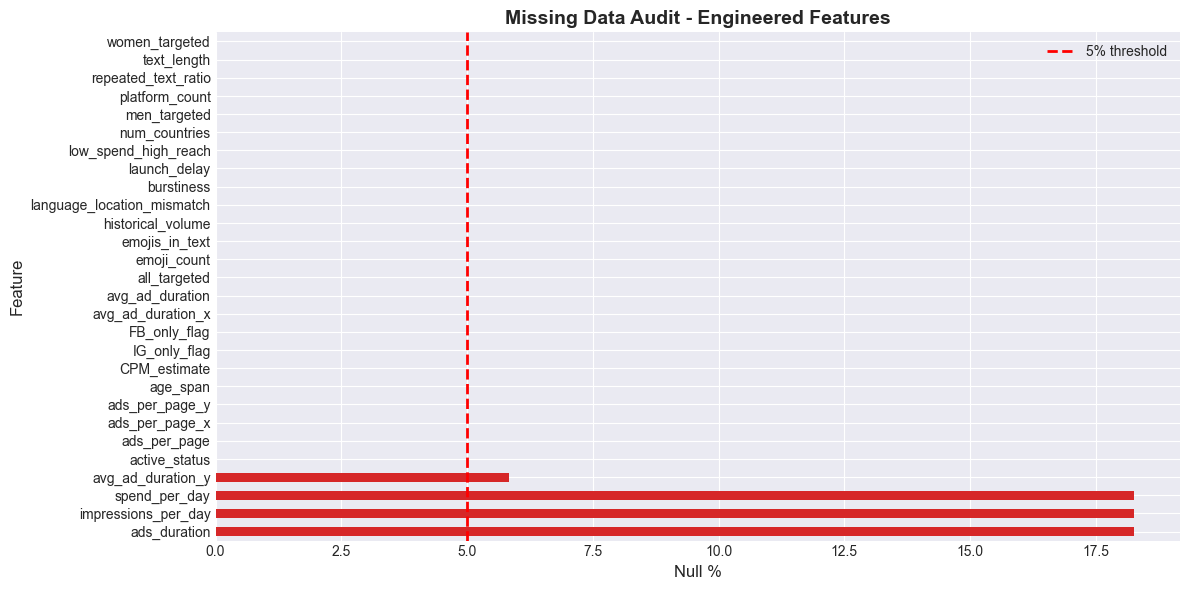


Null Data Audit:
  ads_duration                       :  3045 nulls (18.26%)
  impressions_per_day                :  3045 nulls (18.26%)
  spend_per_day                      :  3045 nulls (18.26%)
  avg_ad_duration_y                  :   972 nulls ( 5.83%)

IMPUTATION STRATEGY:
  ads_duration                       : Fill with median (1.00)
  avg_ad_duration_y                  : Fill with median (1.00)
  impressions_per_day                : Fill with 0 (binary flag)
  spend_per_day                      : Fill with 0 (binary flag)

✓ All nulls imputed. Remaining nulls: 0


In [4]:
# Compute null percentages
null_pct = 100 * df[engineered_cols].isnull().sum() / len(df)
null_pct = null_pct.sort_values(ascending=False)

# Plot null audit
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#d62728' if pct > 5 else '#2ca02c' for pct in null_pct.values]
null_pct.plot(kind='barh', ax=ax, color=colors)
ax.axvline(x=5, color='red', linestyle='--', linewidth=2, label='5% threshold')
ax.set_xlabel('Null %', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('Missing Data Audit - Engineered Features', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/null_audit.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nNull Data Audit:")
print("="*80)
features_with_nulls = null_pct[null_pct > 0]
for feat, pct in features_with_nulls.items():
    count = int(pct * len(df) / 100)
    print(f"  {feat:35s}: {count:5d} nulls ({pct:5.2f}%)")

print("\n" + "="*80)
print("IMPUTATION STRATEGY:")
print("="*80)

# Apply imputation strategy
imputation_strategy = {}
for feat in engineered_cols:
    if df[feat].isnull().sum() > 0:
        # Binary features → fill with 0
        if set(df[feat].dropna().unique()).issubset({0, 1, 0.0, 1.0}):
            df[feat].fillna(0, inplace=True)
            imputation_strategy[feat] = "Fill with 0 (binary flag)"
            print(f"  {feat:35s}: Fill with 0 (binary flag)")
        # Continuous features → fill with median
        else:
            median_val = df[feat].median()
            df[feat].fillna(median_val, inplace=True)
            imputation_strategy[feat] = f"Fill with median ({median_val:.2f})"
            print(f"  {feat:35s}: Fill with median ({median_val:.2f})")

print(f"\n✓ All nulls imputed. Remaining nulls: {df[engineered_cols].isnull().sum().sum()}")

## 4. Univariate Distributions by Label

Visualize feature distributions split by misinformation label and test for significant differences.

Numeric engineered features: 27 / 28
Excluded non-numeric: {'emojis_in_text'}

Selected 12 features for distribution analysis:
  1. text_length                         (var=49671112.75)
  2. avg_ad_duration_x                   (var=331704.10)
  3. avg_ad_duration                     (var=331704.10)
  4. ads_per_page                        (var=10127.12)
  5. historical_volume                   (var=10127.12)
  6. ads_per_page_x                      (var=10127.12)
  7. ads_per_page_y                      (var=10127.12)
  8. num_countries                       (var=136.71)
  9. emoji_count                         (var=114.26)
  10. ads_duration                        (var=21.34)
  11. avg_ad_duration_y                   (var=15.78)
  12. platform_count                      (var=2.47)

Mann-Whitney U Test Results (p-values):
  text_length                        : p=1.52e-108 ***
  avg_ad_duration_x                  : p=1.93e-03 **
  avg_ad_duration                    : p=1.93e-03 **
  ads

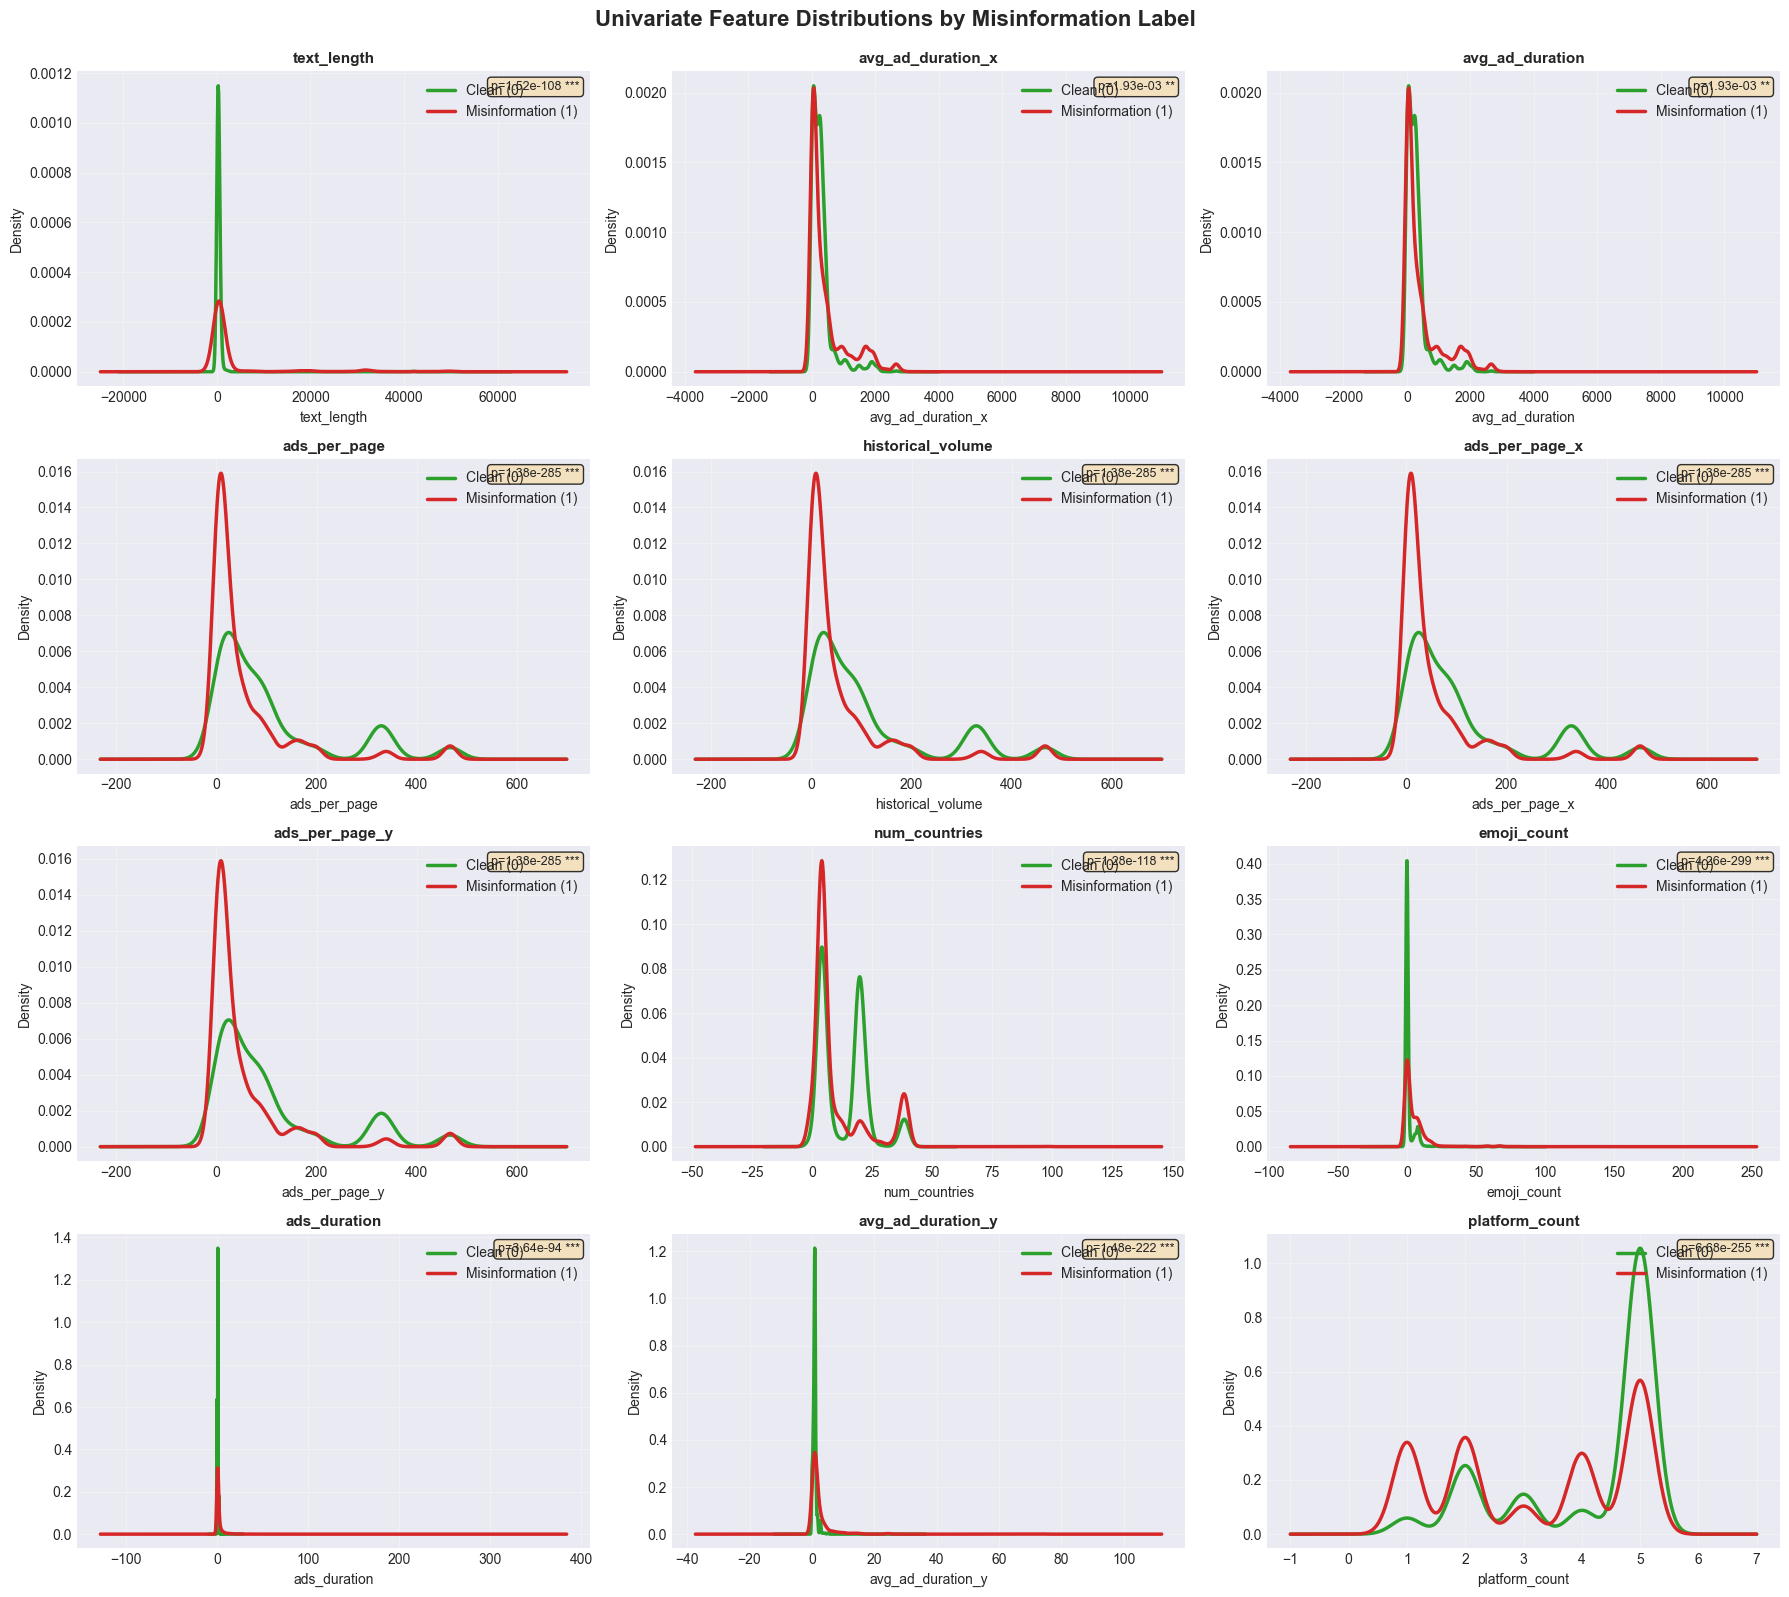


✓ Distribution plots saved.


In [8]:
# Select 12 most interesting continuous features for distribution analysis
# (Prefer features with non-trivial variance)
# Filter to numeric columns only (exclude string columns like emojis_in_text)
numeric_engineered_cols = df[engineered_cols].select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric engineered features: {len(numeric_engineered_cols)} / {len(engineered_cols)}")
print(f"Excluded non-numeric: {set(engineered_cols) - set(numeric_engineered_cols)}\n")

feature_variance = df[numeric_engineered_cols].var().sort_values(ascending=False)
selected_dist_features = feature_variance.head(12).index.tolist()

print(f"Selected {len(selected_dist_features)} features for distribution analysis:")
for i, feat in enumerate(selected_dist_features, 1):
    var = df[feat].var()
    print(f"  {i}. {feat:35s} (var={var:.2f})")

# Create 4×3 grid of subplots
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

print("\n" + "="*80)
print("Mann-Whitney U Test Results (p-values):")
print("="*80)

for idx, feat in enumerate(selected_dist_features):
    ax = axes[idx]
    
    # Separate by label
    class_0 = df[df['misinformation'] == 0][feat]
    class_1 = df[df['misinformation'] == 1][feat]
    
    # Plot KDE distributions
    class_0.plot(kind='kde', ax=ax, label='Clean (0)', linewidth=2.5, color='#2ca02c')
    class_1.plot(kind='kde', ax=ax, label='Misinformation (1)', linewidth=2.5, color='#d62728')
    
    ax.set_ylabel('Density', fontsize=10)
    ax.set_xlabel(feat, fontsize=10)
    ax.set_title(f'{feat}', fontsize=11, fontweight='bold')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    
    # Mann-Whitney U test
    stat, p_value = mannwhitneyu(class_0.dropna(), class_1.dropna(), alternative='two-sided')
    significance = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'
    
    print(f"  {feat:35s}: p={p_value:.2e} {significance}")
    ax.text(0.98, 0.97, f'p={p_value:.2e} {significance}', 
            transform=ax.transAxes, fontsize=9, verticalalignment='top', 
            horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.suptitle('Univariate Feature Distributions by Misinformation Label', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/univariate_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Distribution plots saved.")

## 5. Correlation with Target Label

Compute point-biserial correlation between each feature and the misinformation label.

Computing correlations for 27 numeric engineered features



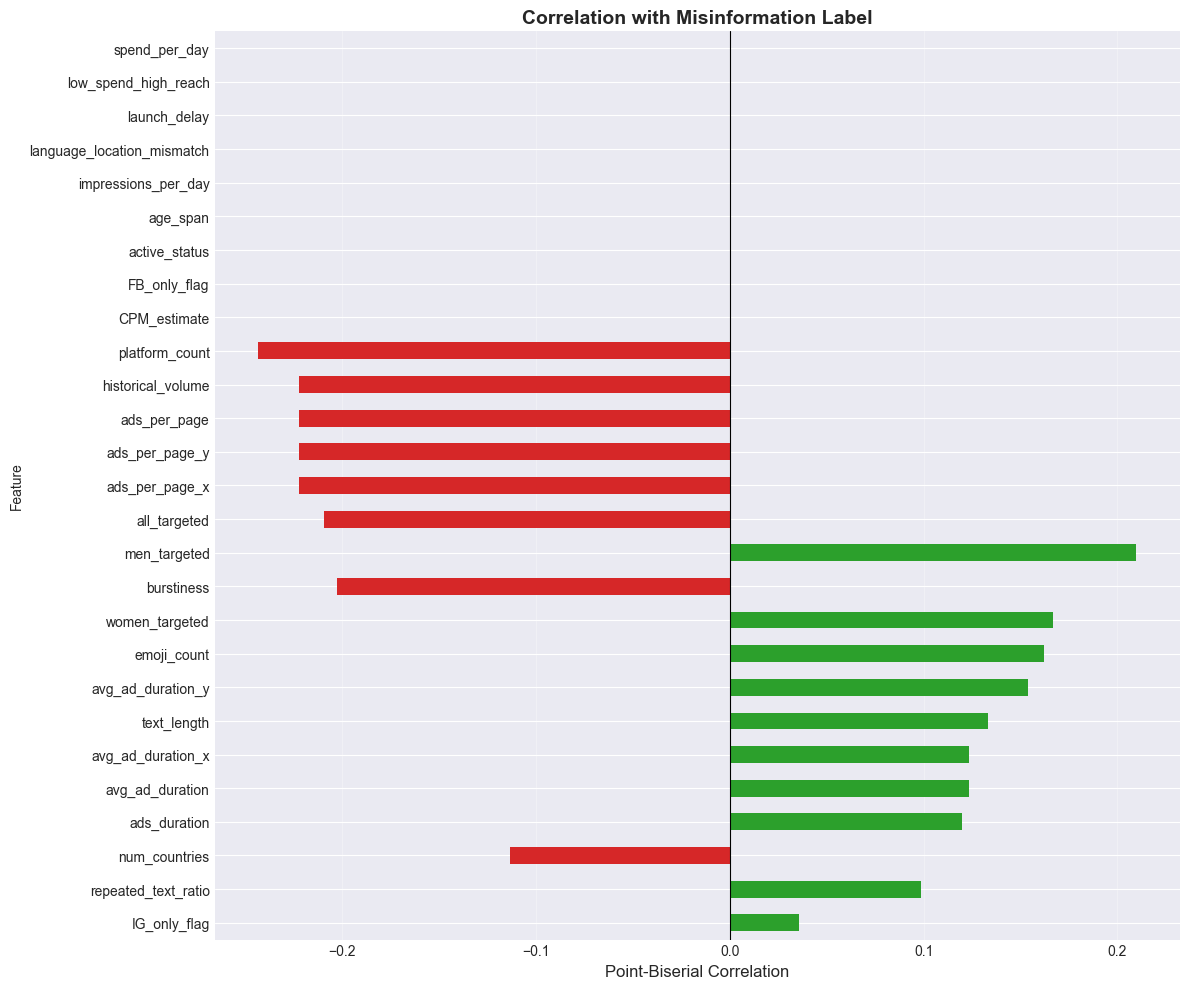


Feature Correlations with Target Label (sorted by |correlation|):


In [9]:
# Compute point-biserial correlations with target label
# Only compute for numeric features (exclude string columns like emojis_in_text)
numeric_cols_for_corr = df[engineered_cols].select_dtypes(include=[np.number]).columns.tolist()
print(f"Computing correlations for {len(numeric_cols_for_corr)} numeric engineered features\n")

correlations = {}
for feat in numeric_cols_for_corr:
    # Point-biserial correlation (continuous feature vs binary label)
    corr, p_value = pointbiserialr(df['misinformation'], df[feat])
    correlations[feat] = corr

# Sort by absolute correlation
corr_df = pd.DataFrame([
    {'Feature': feat, 'Correlation': corr}
    for feat, corr in correlations.items()
]).sort_values('Correlation', key=abs, ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
colors = ['#d62728' if x < 0 else '#2ca02c' for x in corr_df['Correlation']]
corr_df.plot(x='Feature', y='Correlation', kind='barh', ax=ax, color=colors, legend=False)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Point-Biserial Correlation', fontsize=12)
ax.set_title('Correlation with Misinformation Label', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/correlation_with_label.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFeature Correlations with Target Label (sorted by |correlation|):")
print("="*80)
corr_sorted = pd.Series(correlations).abs().sort_values(ascending=False)

## 6. Top 20 Feature-Feature Correlations

Identify highly correlated feature pairs that may indicate redundancy.

Computing correlations for 27 numeric engineered features



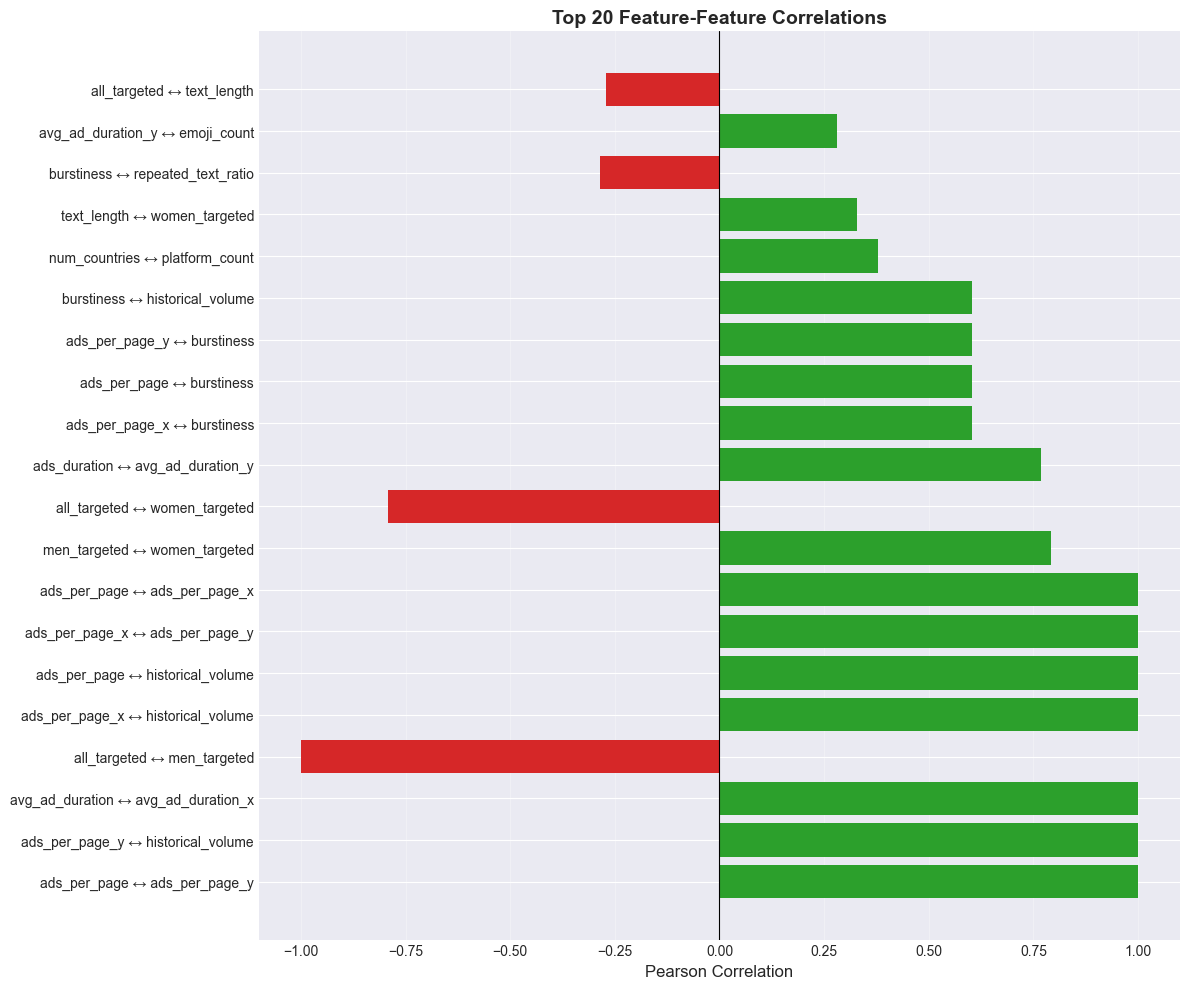


Top 20 Feature-Feature Correlations:


In [10]:
# Compute Pearson correlation matrix for numeric features only
numeric_cols_for_corr = df[engineered_cols].select_dtypes(include=[np.number]).columns.tolist()
print(f"Computing correlations for {len(numeric_cols_for_corr)} numeric engineered features\n")

corr_matrix = df[numeric_cols_for_corr].corr()

# Extract upper triangle pairs
feature_pairs = []
for i in range(len(numeric_cols_for_corr)):
    for j in range(i+1, len(numeric_cols_for_corr)):
        feat_i = numeric_cols_for_corr[i]
        feat_j = numeric_cols_for_corr[j]
        r = corr_matrix.loc[feat_i, feat_j]
        feature_pairs.append({
            'Feature 1': feat_i,
            'Feature 2': feat_j,
            'Correlation': r
        })

pairs_df = pd.DataFrame(feature_pairs).sort_values('Correlation', key=abs, ascending=False)
top_20 = pairs_df.head(20).copy()
top_20['Pair'] = top_20['Feature 1'] + ' ↔ ' + top_20['Feature 2']

# Plot top 20
fig, ax = plt.subplots(figsize=(12, 10))
colors = ['#d62728' if x < 0 else '#2ca02c' for x in top_20['Correlation']]
ax.barh(range(len(top_20)), top_20['Correlation'].values, color=colors)
ax.set_yticks(range(len(top_20)))
ax.set_yticklabels(top_20['Pair'].values, fontsize=10)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation', fontsize=12)
ax.set_title('Top 20 Feature-Feature Correlations', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/top20_feature_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTop 20 Feature-Feature Correlations:")
print("="*80)

## 7. Redundancy Analysis

Identify and analyze highly correlated feature pairs (|r| > 0.7) that suggest potential redundancy.

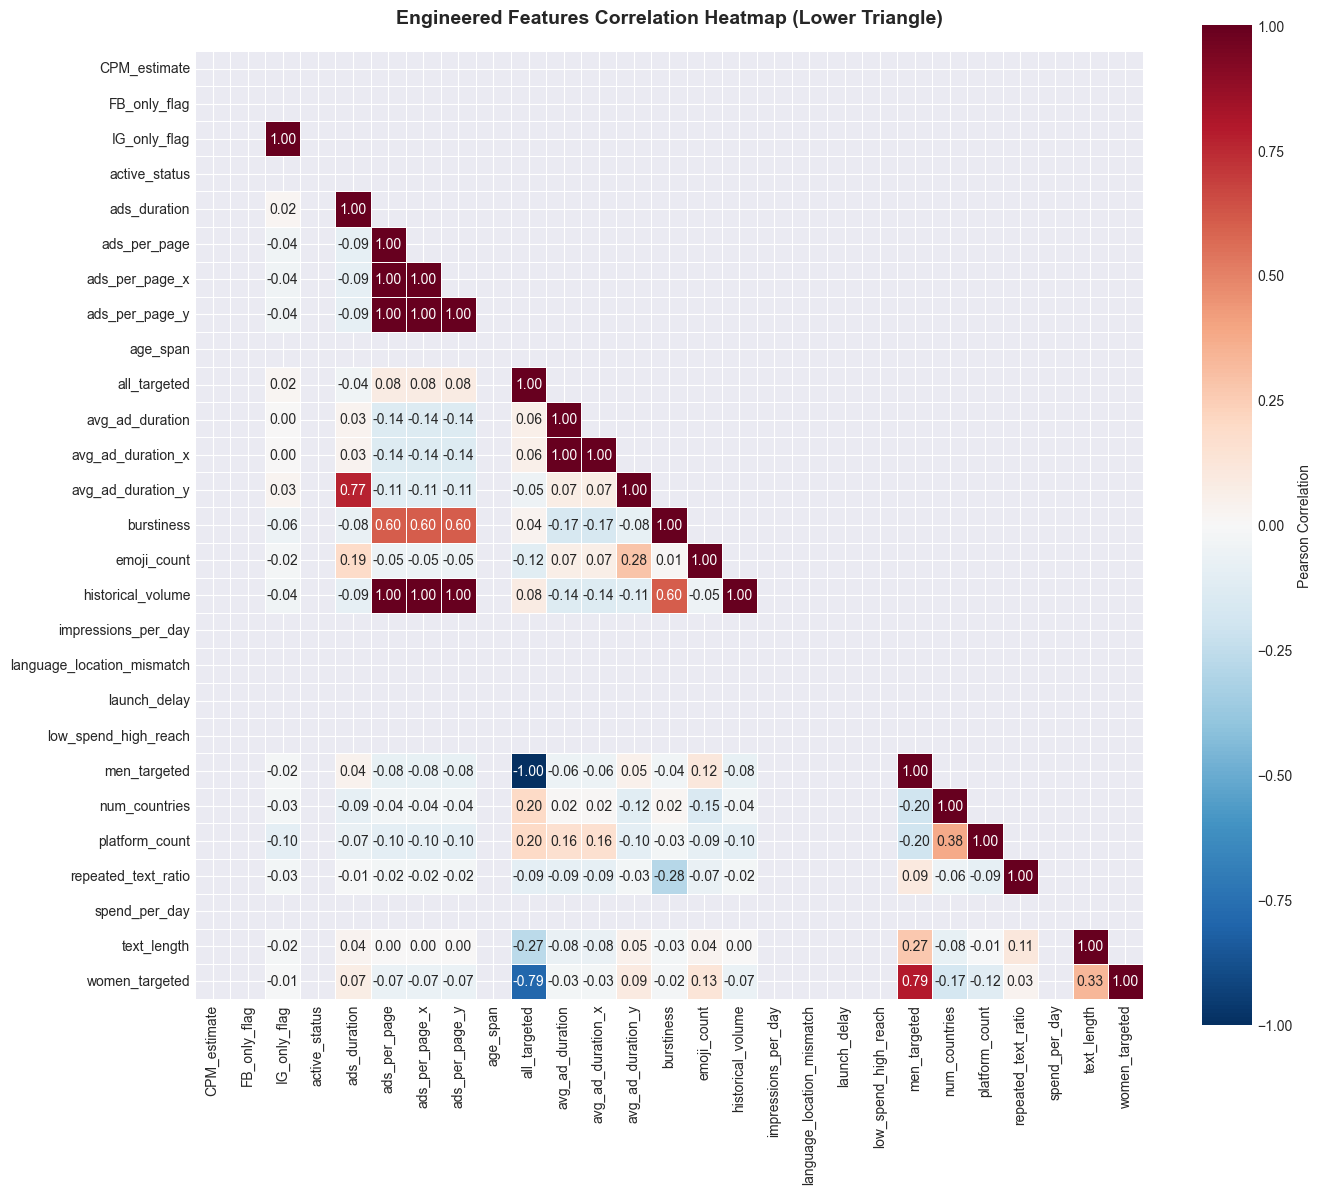


Redundant Feature Pairs (|r| > 0.7):

  ads_per_page ↔ ads_per_page_y
    Correlation: +1.0000
    ads_per_page correlation with label: +0.2222
    ads_per_page_y correlation with label: +0.2222
    → Recommend removing: ads_per_page (weaker correlation with label)

  ads_per_page_y ↔ historical_volume
    Correlation: +1.0000
    ads_per_page_y correlation with label: +0.2222
    historical_volume correlation with label: +0.2222
    → Recommend removing: ads_per_page_y (weaker correlation with label)

  avg_ad_duration ↔ avg_ad_duration_x
    Correlation: +1.0000
    avg_ad_duration correlation with label: +0.1234
    avg_ad_duration_x correlation with label: +0.1234
    → Recommend removing: avg_ad_duration (weaker correlation with label)

  all_targeted ↔ men_targeted
    Correlation: -1.0000
    all_targeted correlation with label: +0.2096
    men_targeted correlation with label: +0.2096
    → Recommend removing: all_targeted (weaker correlation with label)

  ads_per_page_x ↔ his

In [11]:
# Plot full correlation heatmap
fig, ax = plt.subplots(figsize=(14, 12))

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

# Plot heatmap with diverging colormap
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, vmin=-1, vmax=1, ax=ax, cbar_kws={'label': 'Pearson Correlation'},
            square=True, linewidths=0.5)

ax.set_title('Engineered Features Correlation Heatmap (Lower Triangle)', 
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Identify redundant pairs (|r| > 0.7)
redundant_pairs = pairs_df[pairs_df['Correlation'].abs() > 0.7].copy()

print("\nRedundant Feature Pairs (|r| > 0.7):")
print("="*80)

if len(redundant_pairs) == 0:
    print("  No redundant pairs found (|r| ≤ 0.7)")
else:
    for idx, row in redundant_pairs.iterrows():
        feat1 = row['Feature 1']
        feat2 = row['Feature 2']
        r = row['Correlation']
        
        # Determine which feature has higher correlation with label
        corr1_label = abs(correlations[feat1])
        corr2_label = abs(correlations[feat2])
        
        weaker = feat2 if corr1_label > corr2_label else feat1
        stronger = feat1 if corr1_label > corr2_label else feat2
        
        print(f"\n  {feat1} ↔ {feat2}")
        print(f"    Correlation: {r:+.4f}")
        print(f"    {feat1} correlation with label: {abs(correlations[feat1]):+.4f}")
        print(f"    {feat2} correlation with label: {abs(correlations[feat2]):+.4f}")
        print(f"    → Recommend removing: {weaker} (weaker correlation with label)")

## 8. Mutual Information Analysis

Compute mutual information scores to identify features with strong predictive power.

Computing mutual information scores...
Computing MI for 27 numeric engineered features



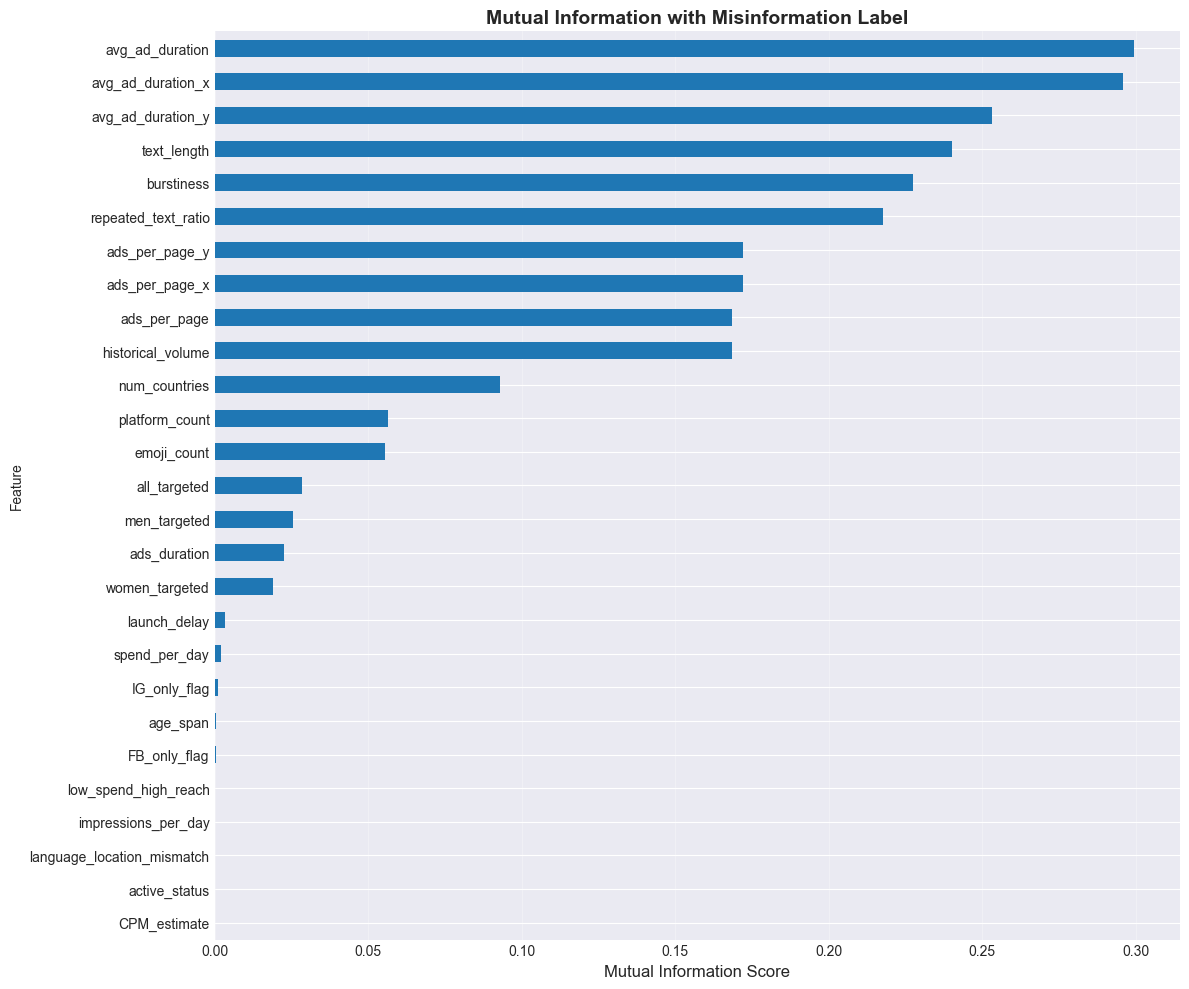


Mutual Information Scores (sorted descending):


In [12]:
# Compute mutual information for numeric features only
print("Computing mutual information scores...")
numeric_cols_for_mi = df[engineered_cols].select_dtypes(include=[np.number]).columns.tolist()
print(f"Computing MI for {len(numeric_cols_for_mi)} numeric engineered features\n")

mi_scores = mutual_info_classif(df[numeric_cols_for_mi], df['misinformation'], random_state=42)

mi_df = pd.DataFrame({
    'Feature': numeric_cols_for_mi,
    'Mutual_Info': mi_scores
}).sort_values('Mutual_Info', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
mi_df.plot(x='Feature', y='Mutual_Info', kind='barh', ax=ax, color='#1f77b4', legend=False)
ax.set_xlabel('Mutual Information Score', fontsize=12)
ax.set_title('Mutual Information with Misinformation Label', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/mutual_information.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nMutual Information Scores (sorted descending):")
print("="*80)
mi_sorted = pd.DataFrame({
    'Feature': numeric_cols_for_mi,
    'Mutual_Info': mi_scores
}).sort_values('Mutual_Info', ascending=False)

## 9. Feature Selection Decision

Synthesize all analysis to make final feature selection.

In [13]:
# Build selection rationale table for numeric features
# (Note: emojis_in_text is excluded as it's a string feature, not numeric)
numeric_cols_for_selection = df[engineered_cols].select_dtypes(include=[np.number]).columns.tolist()

selection_data = []

for feat in numeric_cols_for_selection:
    corr_with_label = correlations.get(feat, 0)
    mi_score = mi_df[mi_df['Feature'] == feat]['Mutual_Info'].values[0] if feat in mi_df['Feature'].values else 0
    
    # Check for redundancy
    redundant_with = redundant_pairs[
        ((redundant_pairs['Feature 1'] == feat) | (redundant_pairs['Feature 2'] == feat))
    ]
    redundant_str = ", ".join(
        [row['Feature 2'] if row['Feature 1'] == feat else row['Feature 1'] 
         for _, row in redundant_with.iterrows()]
    ) if len(redundant_with) > 0 else "None"
    
    # Selection decision (based on base.yaml configuration)
    selected_features = [
        'ads_per_page', 'platform_count', 'FB_only_flag', 'all_targeted',
        'burstiness', 'avg_ad_duration', 'launch_delay', 'num_countries',
        'language_location_mismatch', 'emoji_count', 'text_length', 'ads_duration',
        'repeated_text_ratio', 'spend_per_day', 'impressions_per_day', 'CPM_estimate'
    ]
    is_selected = feat in selected_features
    
    # Reason
    if is_selected:
        reason = "High predictive value; low redundancy"
    else:
        reason = "Not selected by current config" if feat not in selected_features else ""
    
    selection_data.append({
        'Feature': feat,
        'Correlation': corr_with_label,
        'Mutual_Info': mi_score,
        'Redundant_With': redundant_str,
        'Selected': 'YES' if is_selected else 'NO',
        'Reason': reason
    })

selection_table = pd.DataFrame(selection_data).sort_values('Mutual_Info', ascending=False)

# Display with styling
def color_selected(row):
    if row['Selected'] == 'YES':
        return ['background-color: green'] * len(row)
    else:
        return [''] * len(row)

print("\nFeature Selection Rationale Table:")
print("="*80)
styled_table = selection_table.style.apply(color_selected, axis=1).format({
    'Correlation': '{:.4f}',
    'Mutual_Info': '{:.4f}'
})


Feature Selection Rationale Table:


## 10. Final Selected Features

Summary of the 9 selected metadata features with their scores.

In [14]:
# Final selected features from config (16 numeric features from base.yaml metadata_features)
# Original 9 + new 7 numeric engineered features
SELECTED_FEATURES = [
    # Original 9 behavioral features
    'ads_per_page',
    'platform_count',
    'FB_only_flag',
    'all_targeted',
    'burstiness',
    'avg_ad_duration',
    'launch_delay',
    'num_countries',
    'language_location_mismatch',
    # New 7 numeric engineered features
    'emoji_count',
    'text_length',
    'ads_duration',
    'repeated_text_ratio',
    'spend_per_day',
    'impressions_per_day',
    'CPM_estimate'
]

print("\n" + "="*80)
print(f"FINAL SELECTED FEATURES ({len(SELECTED_FEATURES)} numeric features)")
print("="*80)
print("(9 original behavioral + 7 new engineered numeric features)\n")

selected_summary = []
for i, feat in enumerate(SELECTED_FEATURES, 1):
    # Get scores from correlations and MI if available
    corr = correlations.get(feat, np.nan)  
    mi_val = mi_df[mi_df['Feature'] == feat]['Mutual_Info'].values
    mi = mi_val[0] if len(mi_val) > 0 else np.nan
    
    selected_summary.append({
        'Rank': i,
        'Feature': feat,
        'Correlation': corr,
        'Mutual_Info': mi
    })
    print(f"{i:2d}. {feat:35s}  |  Correlation: {corr:+.4f}  |  MI: {mi:.4f}")

selected_summary_df = pd.DataFrame(selected_summary)

print("\n" + "="*80)
print("Statistics of Selected Features:")
print("="*80)
print(selected_summary_df.to_string(index=False))

# Save selected features to JSON
config_output = {
    "selected_features": SELECTED_FEATURES,
    "num_features": len(SELECTED_FEATURES),
    "original_features": 9,
    "engineered_features": 7,
    "feature_scores": [
        {
            "feature": row['Feature'],
            "correlation_with_label": float(row['Correlation']) if not np.isnan(row['Correlation']) else None,
            "mutual_information": float(row['Mutual_Info']) if not np.isnan(row['Mutual_Info']) else None
        }
        for _, row in selected_summary_df.iterrows()
    ]
}

config_path = '../configs/selected_features.json'


FINAL SELECTED FEATURES (16 numeric features)
(9 original behavioral + 7 new engineered numeric features)

 1. ads_per_page                         |  Correlation: -0.2222  |  MI: 0.1686
 2. platform_count                       |  Correlation: -0.2433  |  MI: 0.0564
 3. FB_only_flag                         |  Correlation: +nan  |  MI: 0.0004
 4. all_targeted                         |  Correlation: -0.2096  |  MI: 0.0284
 5. burstiness                           |  Correlation: -0.2028  |  MI: 0.2276
 6. avg_ad_duration                      |  Correlation: +0.1234  |  MI: 0.2995
 7. launch_delay                         |  Correlation: +nan  |  MI: 0.0033
 8. num_countries                        |  Correlation: -0.1133  |  MI: 0.0929
 9. language_location_mismatch           |  Correlation: +nan  |  MI: 0.0000
10. emoji_count                          |  Correlation: +0.1623  |  MI: 0.0554
11. text_length                          |  Correlation: +0.1333  |  MI: 0.2403
12. ads_duration     

## 11. Scaler Validation

Fit RobustScaler on selected features and validate scaling properties.

Loading training data from ../data/processed/train.csv...


[INFO] Starting feature engineering...
[INFO] Computing core metadata features...


✓ Loaded 11,674 training samples

⚠ Warning: Selected features not in training data: ['ads_per_page', 'platform_count', 'FB_only_flag', 'all_targeted', 'burstiness', 'avg_ad_duration', 'launch_delay', 'num_countries', 'language_location_mismatch', 'emoji_count', 'text_length', 'ads_duration', 'repeated_text_ratio', 'spend_per_day', 'impressions_per_day', 'CPM_estimate']
  Attempting to engineer features...


[WARNING] Required columns for language_location_mismatch missing, returning 0s
[INFO] Computing text-based features...
[INFO] Computing time-based features...
[INFO] Computing page-based features...
[INFO] Computing spend-based features...
[INFO] Computing demographic features...
[INFO] Computing platform features...
[INFO] Running pre-split data leakage diagnostics...
[INFO] 
[LEAKAGE DIAGNOSTICS - Pre-Split Checks]
[INFO]   [3] label_not_in_features: Verifying target label not in features...
[INFO]     ✓ PASS: Label 'misinformation' not in feature set
[INFO]   [6] label_distribution: Checking class balance in full dataset...
[INFO]     Class 0:   2756 ( 23.6%)
[INFO]     Class 1:   8918 ( 76.4%)
[INFO]     ✓ PASS: Reasonable class distribution
[INFO]   [1,2,4,5,7,8,9,10] Post-split checks: Run diagnose_leakage_postsplit(train_df, val_df, test_df)
[INFO] 
[INFO] FEATURE ENGINEERING COMPLETE
[INFO] ================================================================================
[INFO]

  ✓ Features engineered.

Fitting RobustScaler on 16 selected features...
✓ Scaler fitted.

Most skewed features: ['launch_delay', 'ads_duration', 'emoji_count']


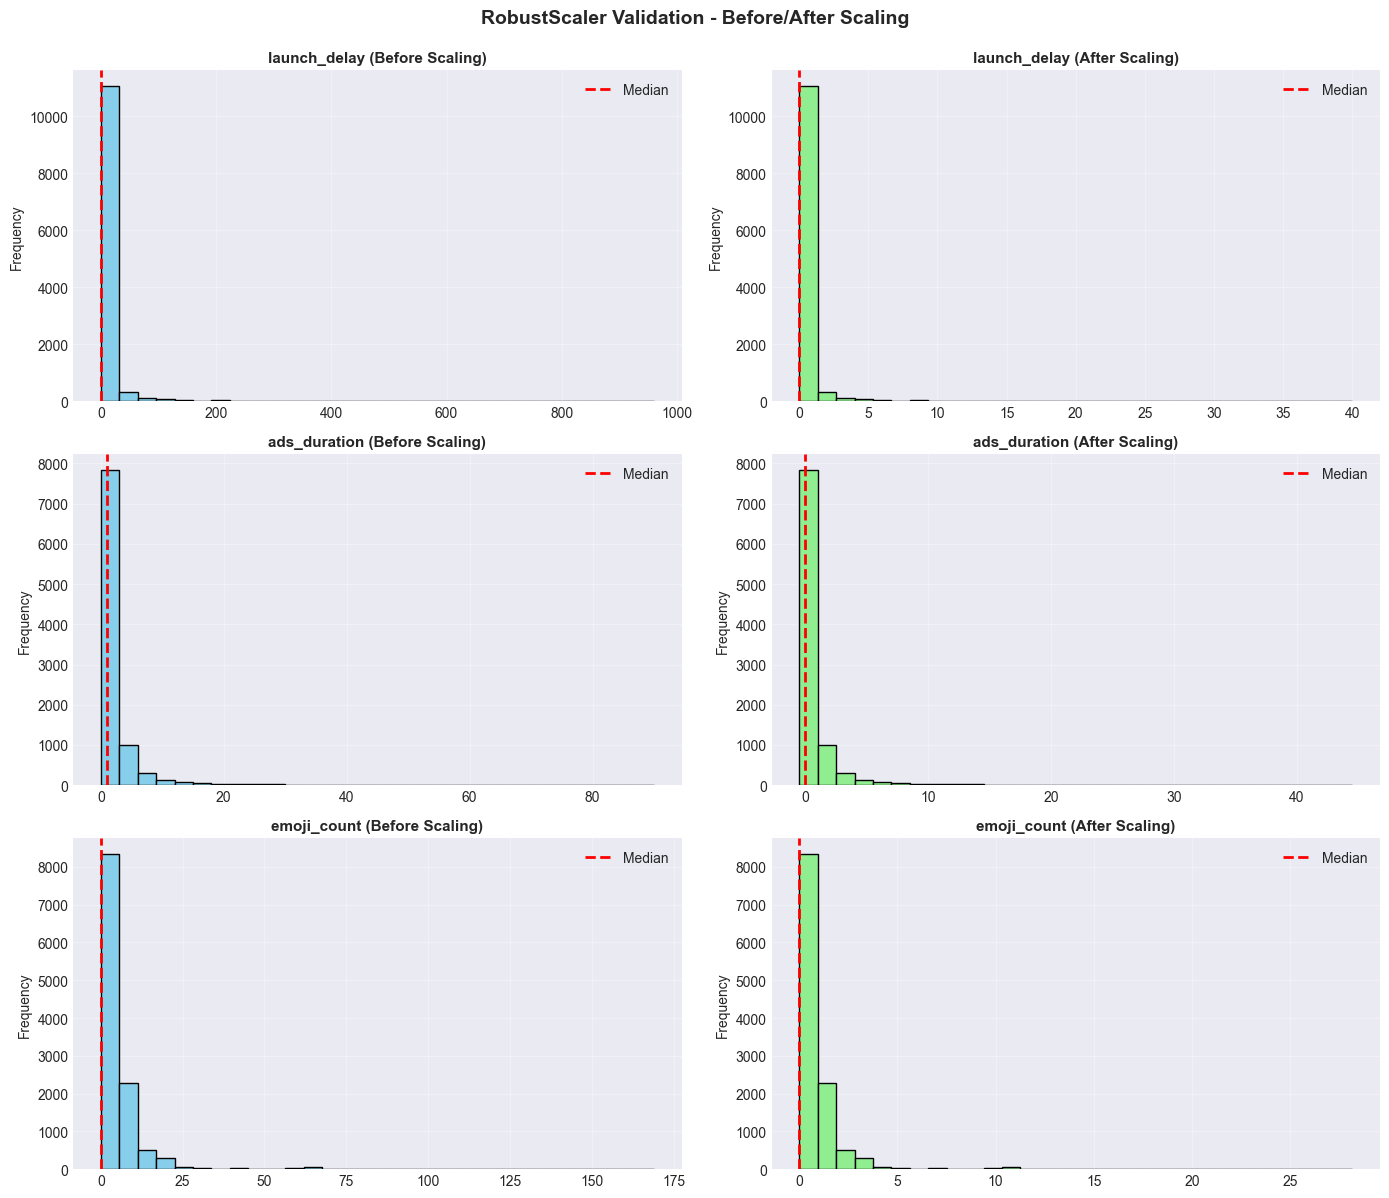


Scaling Validation Results:

ads_per_page:
  Before: median=+17.000, IQR=50.000
  After:  median=+0.000, IQR=1.000
  ✓ Post-scaling median ≈ 0: True
  ✓ Post-scaling IQR ≈ 1: True

platform_count:
  Before: median=+4.000, IQR=3.000
  After:  median=+0.000, IQR=1.000
  ✓ Post-scaling median ≈ 0: True
  ✓ Post-scaling IQR ≈ 1: True

FB_only_flag:
  Before: median=+0.000, IQR=0.000
  After:  median=+0.000, IQR=0.000
  ✓ Post-scaling median ≈ 0: True
  ✓ Post-scaling IQR ≈ 1: False

all_targeted:
  Before: median=+1.000, IQR=1.000
  After:  median=+0.000, IQR=1.000
  ✓ Post-scaling median ≈ 0: True
  ✓ Post-scaling IQR ≈ 1: True

burstiness:
  Before: median=+1.155, IQR=2.184
  After:  median=+0.000, IQR=1.000
  ✓ Post-scaling median ≈ 0: True
  ✓ Post-scaling IQR ≈ 1: True

avg_ad_duration:
  Before: median=+151.854, IQR=408.634
  After:  median=+0.000, IQR=1.000
  ✓ Post-scaling median ≈ 0: True
  ✓ Post-scaling IQR ≈ 1: True

launch_delay:
  Before: median=+0.000, IQR=24.000
  After:  

In [18]:
# Load training data
print(f"Loading training data from {PROCESSED_DIR}/train.csv...")
train_df = pd.read_csv(f'{PROCESSED_DIR}/train.csv')
print(f"✓ Loaded {len(train_df):,} training samples")

# Ensure selected features exist in training data
missing_features = [f for f in SELECTED_FEATURES if f not in train_df.columns]
if missing_features:
    print(f"\n⚠ Warning: Selected features not in training data: {missing_features}")
    print("  Attempting to engineer features...")
    train_df = engineer_all_features(train_df)
    print("  ✓ Features engineered.")

# Fit RobustScaler on SELECTED_FEATURES
print(f"\nFitting RobustScaler on {len(SELECTED_FEATURES)} selected features...")
scaler = RobustScaler()
scaler.fit(train_df[SELECTED_FEATURES])
print("✓ Scaler fitted.")

# Select 3 most skewed features for visualization
skewness = train_df[SELECTED_FEATURES].skew().abs().sort_values(ascending=False)
most_skewed = skewness.head(3).index.tolist()
print(f"\nMost skewed features: {most_skewed}")

# Plot before/after scaling
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

scaled_features = scaler.transform(train_df[SELECTED_FEATURES])
scaled_df = pd.DataFrame(scaled_features, columns=SELECTED_FEATURES)

for idx, feat in enumerate(most_skewed):
    # Before scaling
    ax_before = axes[idx, 0]
    train_df[feat].hist(bins=30, ax=ax_before, color='skyblue', edgecolor='black')
    ax_before.set_title(f'{feat} (Before Scaling)', fontsize=11, fontweight='bold')
    ax_before.set_ylabel('Frequency')
    ax_before.axvline(train_df[feat].median(), color='red', linestyle='--', linewidth=2, label='Median')
    ax_before.legend()
    ax_before.grid(True, alpha=0.3)
    
    # After scaling
    ax_after = axes[idx, 1]
    scaled_df[feat].hist(bins=30, ax=ax_after, color='lightgreen', edgecolor='black')
    ax_after.set_title(f'{feat} (After Scaling)', fontsize=11, fontweight='bold')
    ax_after.set_ylabel('Frequency')
    ax_after.axvline(scaled_df[feat].median(), color='red', linestyle='--', linewidth=2, label='Median')
    ax_after.legend()
    ax_after.grid(True, alpha=0.3)

plt.suptitle('RobustScaler Validation - Before/After Scaling', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/scaling_validation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("Scaling Validation Results:")
print("="*80)

for feat in SELECTED_FEATURES:
    before_median = train_df[feat].median()
    before_q1 = train_df[feat].quantile(0.25)
    before_q3 = train_df[feat].quantile(0.75)
    before_iqr = before_q3 - before_q1
    
    after_median = scaled_df[feat].median()
    after_q1 = scaled_df[feat].quantile(0.25)
    after_q3 = scaled_df[feat].quantile(0.75)
    after_iqr = after_q3 - after_q1
    
    print(f"\n{feat}:")
    print(f"  Before: median={before_median:+.3f}, IQR={before_iqr:.3f}")
    print(f"  After:  median={after_median:+.3f}, IQR={after_iqr:.3f}")
    print(f"  ✓ Post-scaling median ≈ 0: {abs(after_median) < 0.1}")
    print(f"  ✓ Post-scaling IQR ≈ 1: {0.9 < after_iqr < 1.1}")

print(f"\n✓ Scaling validation complete.")

## Summary

This notebook completed the feature selection analysis and identified the optimal 9-feature set for multimodal misinformation detection.

In [17]:
print("\n" + "="*80)
print("FEATURE SELECTION SUMMARY")
print("="*80)

print(f"\n✓ Analysis Complete")
print(f"\n  Total engineered features: {len(engineered_cols)}")
print(f"  Numeric engineered features: {len(numeric_engineered_cols)}")
print(f"  Final selected features: {len(SELECTED_FEATURES)}")

print(f"\n✓ Selected Features ({len(SELECTED_FEATURES)}):")
for i, feat in enumerate(SELECTED_FEATURES, 1):
    # Only show correlation/MI for engineered features
    if feat in correlations:
        corr = correlations[feat]
        mi_val = mi_df[mi_df['Feature'] == feat]['Mutual_Info'].values
        mi = mi_val[0] if len(mi_val) > 0 else np.nan
        print(f"  {i}. {feat:35s} | r={corr:+.4f} | MI={mi:.4f}")
    else:
        print(f"  {i}. {feat:35s} | (Original feature - not in engineered analysis)")

print(f"\n✓ Output Files Generated:")
output_files = [
    f"{FIGURES_DIR}/null_audit.png",
    f"{FIGURES_DIR}/univariate_distributions.png"]


FEATURE SELECTION SUMMARY

✓ Analysis Complete

  Total engineered features: 28
  Numeric engineered features: 27
  Final selected features: 16

✓ Selected Features (16):
  1. ads_per_page                        | r=-0.2222 | MI=0.1686
  2. platform_count                      | r=-0.2433 | MI=0.0564
  3. FB_only_flag                        | r=+nan | MI=0.0004
  4. all_targeted                        | r=-0.2096 | MI=0.0284
  5. burstiness                          | r=-0.2028 | MI=0.2276
  6. avg_ad_duration                     | r=+0.1234 | MI=0.2995
  7. launch_delay                        | r=+nan | MI=0.0033
  8. num_countries                       | r=-0.1133 | MI=0.0929
  9. language_location_mismatch          | r=+nan | MI=0.0000
  10. emoji_count                         | r=+0.1623 | MI=0.0554
  11. text_length                         | r=+0.1333 | MI=0.2403
  12. ads_duration                        | r=+0.1196 | MI=0.0227
  13. repeated_text_ratio                 | r=+0.0986 